Enter ticker:  KLAR


[*********************100%***********************]  1 of 1 completed


Starting price = $18.29
Average ending price = $7.30
Median ending price = $5.65
5th percentile = $1.67
95th percentile = $18.87
Probability of gain = 5.40%


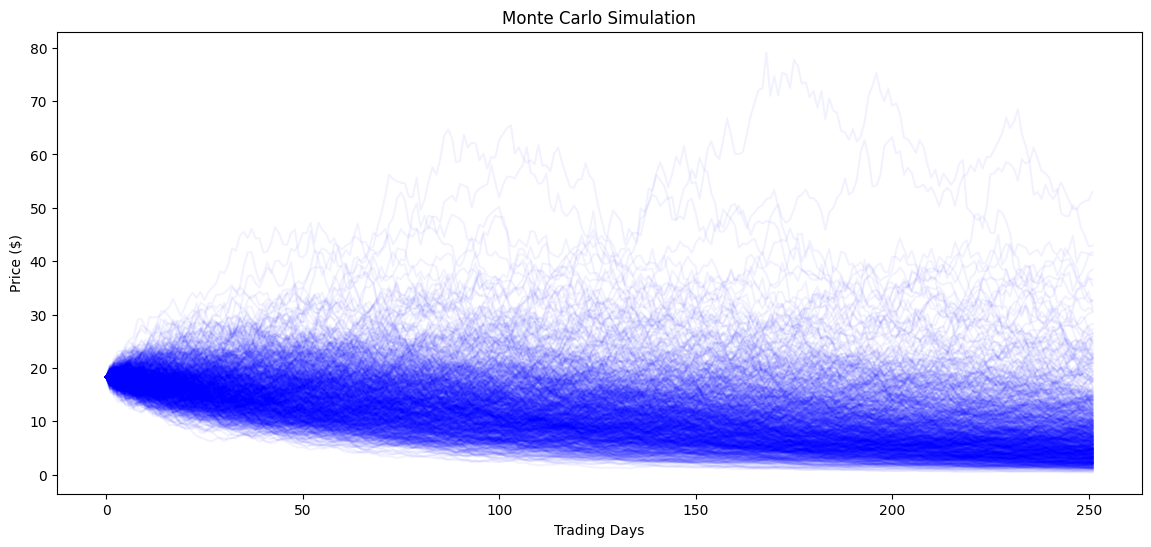

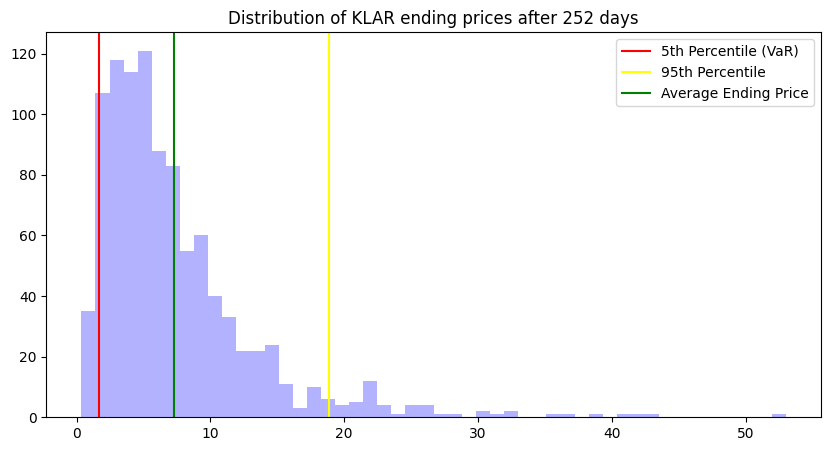

95% VaR = $16.62


In [20]:
import numpy as np
import pandas as pd
import yfinance as yf 
import matplotlib.pyplot as plt

#pull company data 
ticker = input("Enter ticker: ") 
data = yf.download(ticker, start="2020-01-01", end="2026-06-01")
data.columns = data.columns.get_level_values(0) #flatten MultiIndex to a single index 

#calculate returns 
returns = data["Close"].pct_change().dropna()
mean = returns.mean()
std = returns.std()

#monte carlo simulation
days = 252
simulations = 1000
start_price = data["Close"].iloc[-1]

results = np.zeros((days, simulations)) #define results to be a blank DataFrame of dimensions 252 x 1000
for i in range(simulations):
    price = np.zeros(days) #price starts as a 252-row long column of zeroes
    price[0] = start_price
    for d in range (1, days):
        shock = np.random.normal(mean, std) #generate random daily price movements according to the stock's standard deviation
        price[d] = price[d-1]*(1 + shock) #scale the previous day's price by the shock to calculate today's price 
    results[:, i] = price #fill every row in the ith column (price) of the DataFrame (results) with these values 

#plot results 
plt.figure(figsize=(14, 6))
plt.plot(results, alpha=0.05, color="blue")
plt.title("Monte Carlo Simulation") 
plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.show

#output stats
final_prices = results[-1]
print(f"Starting price = ${start_price:.2f}")
print(f"Average ending price = ${np.mean(final_prices):.2f}")
print(f"Median ending price = ${np.median(final_prices):.2f}")
print(f"5th percentile = ${np.percentile(final_prices, 5):.2f}")
print(f"95th percentile = ${np.percentile(final_prices, 95):.2f}")
print(f"Probability of gain = {(final_prices > start_price).mean() * 100:.2f}%") #percent of simulations that resulted in a gain

#plot histogram 
plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=50, color="blue", alpha=0.3) 
plt.axvline(np.percentile(final_prices, 5), color="red", label="5th Percentile (VaR)") 
plt.axvline(np.percentile(final_prices, 95), color="yellow", label="95th Percentile") 
plt.axvline(np.mean(final_prices), color="green", label="Average Ending Price") 
plt.title(f"Distribution of {ticker} ending prices after {days} days") 
plt.legend()
plt.show()

#calculate value at risk 
VaR = start_price - np.percentile(final_prices, 5)
print(f"95% VaR = ${VaR:.2f}")  #there is a 5% chance of losing more than this value, aka 95% certainty of not losing more than this 